1. Импортируем необходимые библиотеки

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# Настройка графиков
%matplotlib inline
sns.set_style("whitegrid")

2. Загрузка данных

In [16]:
print("=== 2. Загрузка данных ===")
df = pd.read_csv('heart.csv')
print(f"Размер данных: {df.shape}")
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nСтатистика:")
print(df.describe())

=== 2. Загрузка данных ===
Размер данных: (303, 14)

Первые 5 строк:
   age  sex  cp  trtbps  chol  fbs  restecg  thalachh  exng  oldpeak  slp  \
0   63    1   3     145   233    1        0       150     0      2.3    0   
1   37    1   2     130   250    0        1       187     0      3.5    0   
2   41    0   1     130   204    0        0       172     0      1.4    2   
3   56    1   1     120   236    0        1       178     0      0.8    2   
4   57    0   0     120   354    0        1       163     1      0.6    2   

   caa  thall  output  
0    0      1       1  
1    0      2       1  
2    0      2       1  
3    0      2       1  
4    0      2       1  

Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps  

3. Предобработка данных

In [17]:
# Проверка пропусков
print(f"Пропуски: {df.isnull().sum().sum()}")

# Удаление дубликатов
df = df.drop_duplicates().reset_index(drop=True)
print(f"Дубликаты после удаления: {df.duplicated().sum()}")

# Кодирование категориальных признаков
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Категориальные признаки: {list(categorical_cols)}")

df_processed = df.copy()
le = LabelEncoder()
for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Нормализация данных
scaler = StandardScaler()
features = [col for col in df_processed.columns if col != 'output']
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_processed[features]),
    columns=features
)
df_scaled['output'] = df_processed['output'].values

print(f"Размер после предобработки: {df_scaled.shape}")
print("Первые 5 строк после нормализации:")
print(df_scaled.head())

Пропуски: 0
Дубликаты после удаления: 0
Категориальные признаки: []
Размер после предобработки: (302, 14)
Первые 5 строк после нормализации:
        age       sex        cp    trtbps      chol       fbs   restecg  \
0  0.949794  0.682656  1.976470  0.764066 -0.261285  2.389793 -1.002541   
1 -1.928548  0.682656  1.005911 -0.091401  0.067741 -0.418446  0.901657   
2 -1.485726 -1.464866  0.035352 -0.091401 -0.822564 -0.418446 -1.002541   
3  0.174856  0.682656  0.035352 -0.661712 -0.203222 -0.418446  0.901657   
4  0.285561 -1.464866 -0.935208 -0.661712  2.080602 -0.418446  0.901657   

   thalachh      exng   oldpeak       slp       caa     thall  output  
0  0.018826 -0.698344  1.084022 -2.271182 -0.714911 -2.147955       1  
1  1.636979 -0.698344  2.118926 -2.271182 -0.714911 -0.513994       1  
2  0.980971 -0.698344  0.307844  0.979514 -0.714911 -0.513994       1  
3  1.243374 -0.698344 -0.209608  0.979514 -0.714911 -0.513994       1  
4  0.587366  1.431958 -0.382092  0.979514 -0.714

4. Разделение на обучающую и тестовую выборки

In [18]:
X = df_scaled.drop('output', axis=1)
y = df_scaled['output']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Распределение классов в обучающей: {y_train.value_counts().to_dict()}")
print(f"Распределение классов в тестовой: {y_test.value_counts().to_dict()}")

Обучающая выборка: (241, 13)
Тестовая выборка: (61, 13)
Распределение классов в обучающей: {1: 131, 0: 110}
Распределение классов в тестовой: {1: 33, 0: 28}


5. Создание и обучение базовой модели Random Forest

In [19]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

print(f"Accuracy базовой модели: {accuracy_score(y_test, y_pred_base):.4f}")
print("\nClassification Report (базовая модель):")
print(classification_report(y_test, y_pred_base, target_names=['Здоров (0)', 'Болен (1)']))

Accuracy базовой модели: 0.7869

Classification Report (базовая модель):
              precision    recall  f1-score   support

  Здоров (0)       0.86      0.64      0.73        28
   Болен (1)       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61



6. Подбор гиперпараметров с помощью GridSearchCV

In [22]:
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print("Параметры для поиска:")
for key, value in param_dist.items():
    print(f"  {key}: {value}")

# RandomizedSearchCV - ищет случайные комбинации
random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,  # Количество случайных комбинаций
    cv=3,       # 3-кратная кросс-валидация
    n_jobs=-1,
    scoring='accuracy',
    random_state=42,
    verbose=1
)

print("\nЗапуск поиска параметров...")
random_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {random_search.best_params_}")
print(f"Лучшая точность (кросс-валидация): {random_search.best_score_:.4f}")

# Обучение модели с лучшими параметрами
rf_best = random_search.best_estimator_
y_pred_best = rf_best.predict(X_test)

Параметры для поиска:
  n_estimators: [50, 100, 200, 300]
  max_depth: [5, 10, 15, 20, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  max_features: ['sqrt', 'log2']

Запуск поиска параметров...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Лучшие параметры: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10}
Лучшая точность (кросс-валидация): 0.8508


7. Оценка корректности модели


Accuracy улучшенной модели: 0.8197

Classification Report (улучшенная модель):
              precision    recall  f1-score   support

  Здоров (0)       0.90      0.68      0.78        28
   Болен (1)       0.78      0.94      0.85        33

    accuracy                           0.82        61
   macro avg       0.84      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61


Confusion Matrix:
[[19  9]
 [ 2 31]]


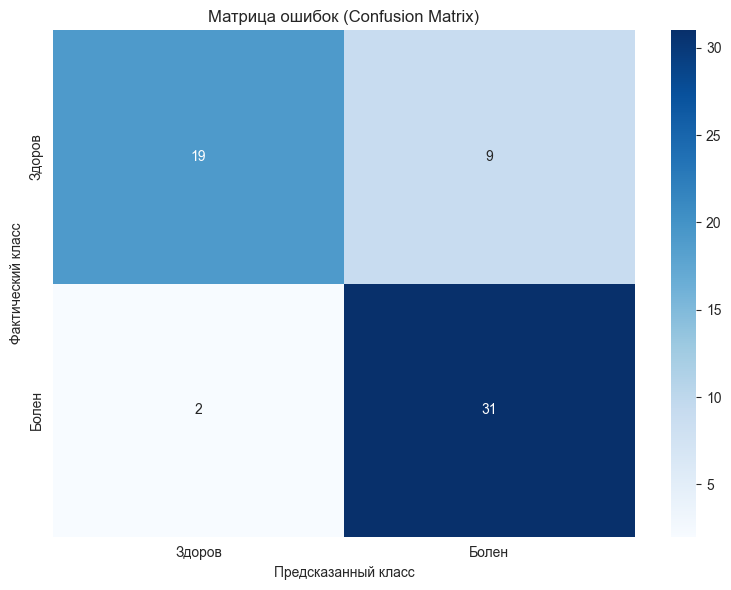

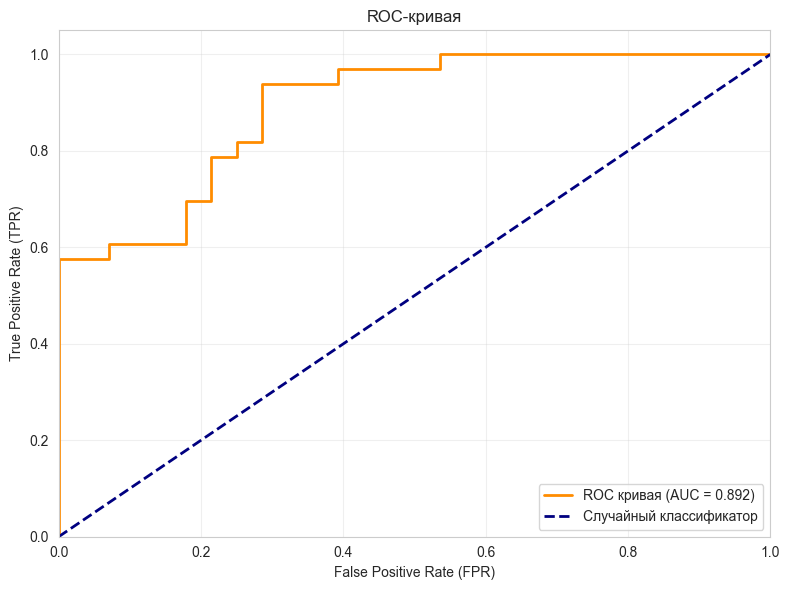


=== Важность признаков ===
 feature  importance
      cp    0.209912
   thall    0.137182
 oldpeak    0.120191
     caa    0.101399
thalachh    0.099750
    exng    0.083824
    chol    0.060214
     age    0.053669
     slp    0.047129
  trtbps    0.039008
     sex    0.028286
 restecg    0.015683
     fbs    0.003752


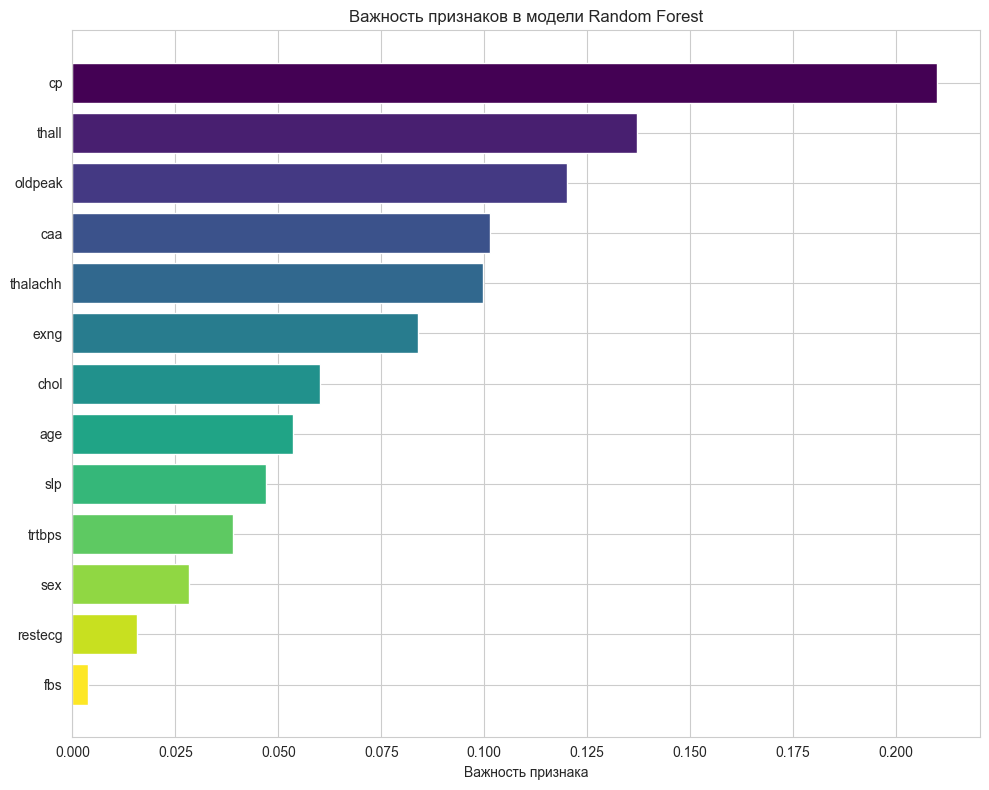


=== Сравнение моделей ===
Метрика              Базовая модель       Улучшенная модель   
------------------------------------------------------------
Accuracy             0.7869               0.8197              

=== Интерпретация результатов ===
1. Модель Random Forest предсказывает наличие сердечного заболевания с точностью 82.0%
2. AUC-ROC = 0.892 — хорошее качество классификации
3. Наиболее важные признаки для предсказания:
   - cp: 0.2099
   - thall: 0.1372
   - oldpeak: 0.1202
   - caa: 0.1014
   - thalachh: 0.0998


In [21]:
print(f"\nAccuracy улучшенной модели: {accuracy_score(y_test, y_pred_best):.4f}")

print("\nClassification Report (улучшенная модель):")
print(classification_report(y_test, y_pred_best, target_names=['Здоров (0)', 'Болен (1)']))

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(cm)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Здоров', 'Болен'], 
            yticklabels=['Здоров', 'Болен'])
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Фактический класс')
plt.tight_layout()
plt.show()

# ROC-кривая и AUC
y_score = rf_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC кривая (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный классификатор')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Важность признаков ===")
print(feature_importance.to_string(index=False))

# Визуализация важности признаков
plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
plt.barh(feature_importance['feature'], feature_importance['importance'], color=colors)
plt.xlabel('Важность признака')
plt.title('Важность признаков в модели Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Сравнение базовой и улучшенной модели
print("\n=== Сравнение моделей ===")
print(f"{'Метрика':<20} {'Базовая модель':<20} {'Улучшенная модель':<20}")
print("-" * 60)
print(f"{'Accuracy':<20} {accuracy_score(y_test, y_pred_base):<20.4f} {accuracy_score(y_test, y_pred_best):<20.4f}")

# Интерпретация результатов
print("\n=== Интерпретация результатов ===")
print(f"1. Модель Random Forest предсказывает наличие сердечного заболевания с точностью {accuracy_score(y_test, y_pred_best):.1%}")
print(f"2. AUC-ROC = {roc_auc:.3f} — {'отличное' if roc_auc > 0.9 else 'хорошее' if roc_auc > 0.8 else 'удовлетворительное'} качество классификации")
print("3. Наиболее важные признаки для предсказания:")
for i in range(5):
    print(f"   - {feature_importance.iloc[i]['feature']}: {feature_importance.iloc[i]['importance']:.4f}")